In [1]:
import os

import pandas as pd
import scanpy as sc

import DeconV as dv

In [6]:
wrkdir = os.path.join("..", "..", "..", "..", "data", "xin")
reference_file = os.path.join(wrkdir, "sc.txt")
reference_mdata_file = os.path.join(wrkdir, "pdata.txt")
bulk_file = os.path.join(wrkdir, "bulk.txt")

cell_types = ["alpha", "delta", "gamma", "beta"]

In [8]:
adata = sc.read_csv(reference_file, first_column_names=True, delimiter="\t")

pheno_df = pd.read_table(reference_mdata_file, index_col=0)
pheno_df.index.name = None
common_cells = list(set(pheno_df.index.tolist()) & set(adata.obs_names.tolist()))


adata = adata[common_cells, :].copy()
pheno_df = pheno_df.loc[common_cells, :].copy()
adata.obs["labels"] = pheno_df["cellType"].tolist()
adata.obs["labels"] = adata.obs["labels"].astype("category")

adata = adata[adata.obs["labels"].astype("str").isin(cell_types), :].copy()

bulk_df = pd.read_table(bulk_file, index_col=None)
if bulk_df.iloc[:,0].dtype == "O":
    bulk_df.set_index(bulk_df.columns[0], inplace=True)
print(f"bulk RNA-seq data - samples: {bulk_df.shape[0]}, genes: {bulk_df.shape[1]}")

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_counts=100)

adata = dv.tl.combine(adata, bulk_df)

adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=None)
adata.layers["ncounts"] = adata.X.copy()
sc.pp.log1p(adata)

adata.obs.groupby("labels").size()

bulk RNA-seq data - samples: 18, genes: 39849
scRNA-seq data - cells: 748, genes: 15029
bulk RNA-seq data - samples: 18, genes: 15029


labels
alpha    443
beta     171
delta     59
gamma     75
dtype: int64

In [9]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

/home/lutrarutra/.pyenv/versions/3.10.9/envs/lst/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


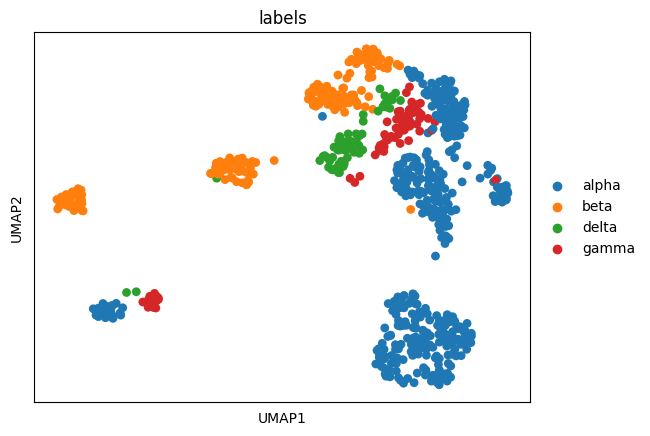

In [10]:
sc.tl.leiden(adata, resolution=0.1)
# adata.obs["cell_type"] = adata.obs["leiden"].astype("category").cat.rename_categories(["MDA-MB-438", "MCF7", "HF"])
adata.obs.drop(columns=["leiden"], inplace=True)
sc.pl.umap(adata, color=["labels"])

In [11]:
# Scaden
# bulk
bulk_df.T.to_csv(os.path.join("data", "xin_bulk_data.txt"), sep="\t")
# count matrix
pd.DataFrame(adata.layers["ncounts"], index=adata.obs_names, columns=adata.var_names).reset_index(drop=True).to_csv(os.path.join("data", "xin_counts.txt"), sep="\t")
# cell types
adata.obs.rename(columns={"labels": "Celltype"})["Celltype"].to_csv(os.path.join("data", "xin_celltypes.txt"), index=False)